# Real-Time Bitcoin Sentiment Analysis

This notebook demonstrates a pipeline for scraping Bitcoin-related tweets, preprocessing them with spaCy, performing sentiment analysis, correlating with Bitcoin prices, and visualizing the results with enhanced correlation measures.

## Overview of Steps
1. **Data Ingestion**: Scrape real-time Bitcoin-related tweets using Selenium.
2. **Data Preprocessing**: Clean and preprocess tweets using spaCy for tokenization, stop-word removal, lemmatization, and Named Entity Recognition (NER).
3. **Sentiment Analysis**: Analyze sentiment and categorize tweets.
4. **Correlation with Bitcoin Prices**: Fetch Bitcoin price data from CoinGecko and compute multiple correlation measures.
5. **Visualizations**: Plot sentiment trends, price trends, sentiment distribution, cumulative sentiment, correlation heatmap, and rolling correlation.

## Step 1: Data Ingestion - Scrape Tweets

We use the `BitcoinSentimentAnalyzer` class to scrape tweets containing the keyword 'Bitcoin'.

In [1]:
from Bitcoin_API import BitcoinSentimentAnalyzer
import pandas as pd

# Initialize the analyzer with the ChromeDriver path and X credentials
analyzer = BitcoinSentimentAnalyzer(
    chromedriver_path=r"C:\Users\siddh\src\tutorials1\DATA605\Spring2025\projects\TutorTask204_Spring2025_RealTime_Bitcoin_Sentiment_Analysis_spaCy_Selenium\chromedriver.exe",
    x_username="siddhirohantest",
    x_password="testing@123"
)

# Scrape tweets
tweets = analyzer.scrape_tweets(keywords=["Bitcoin", "BTC"], max_tweets=100)

# Store tweets in a DataFrame
tweets_df = pd.DataFrame(tweets)
tweets_df.head()

,text,timestamp
0,Savings are a prerequisite for maintaining and...,2025-05-16T08:15:20.464038
1,UPDATE:\nUtah Retirement Systems boosted $MST...,2025-05-16T08:15:20.475417
2,"not ALL Italians are in the cosa nostra, if u ...",2025-05-16T08:15:22.516276
3,Russia's central bank reports Bitcoin as the ...,2025-05-16T08:15:22.525318
4,,2025-05-16T08:15:22.533262


## Step 2: Data Preprocessing - Clean and Preprocess Tweets

We preprocess the tweets using spaCy for tokenization, stop-word removal, lemmatization, and Named Entity Recognition (NER). Sentiment analysis is also performed to assign scores and categorize tweets.

In [2]:
# Preprocess tweets
processed_tweets = analyzer.preprocess_tweets(tweets)

# Analyze sentiment
tweets_with_sentiment = analyzer.analyze_sentiment(processed_tweets)

# Store processed tweets with sentiment in a DataFrame
processed_df = pd.DataFrame(tweets_with_sentiment)
processed_df[['text', 'sentiment', 'sentiment_category', 'coins']].head()

,text,sentiment,sentiment_category,coins
0,saving prerequisite maintain raise standard li...,0.7506,positive,[]
1,update \n utah retirement systems boost $ mstr...,0.8176,positive,[Bitcoin]
2,italians cosa nostra u drift,0.0000,neutral,[]
3,russia central bank report bitcoin perform inv...,0.0000,neutral,[Bitcoin]
4,,0.0000,neutral,[]


## Step 3: Correlation with Bitcoin Prices - Fetch Prices and Analyze Correlation

We fetch Bitcoin price data from CoinGecko, store it with sentiment scores, and compute the correlation.

In [3]:
# Fetch Bitcoin price data
price_df = analyzer.fetch_bitcoin_price()

# Correlate sentiment with price
combined_df, correlations = analyzer.correlate_sentiment_price(tweets_with_sentiment, price_df)

# Display correlation coefficients
print("Correlation between sentiment and Bitcoin price:")
for method, value in correlations.items():
    print(f"{method.capitalize()}: {value:.4f}")

combined_df.head()

Correlation between sentiment and Bitcoin price:
Pearson: -0.0245
Spearman: -0.0341
Kendall: -0.0189
Lagged_pearson: -0.0133


,timestamp,sentiment,price_timestamp,price,price_change,cumulative_sentiment,sentiment_lagged,rolling_corr
0,2025-05-16 08:15:20.464038,0.7506,2025-05-15 12:21:01.480,102348.409017,NaN,0.7506,NaN,0.000000
1,2025-05-16 08:15:20.475417,0.8176,2025-05-15 12:26:35.897,102435.844604,0.000854,1.5682,0.7506,0.000000
2,2025-05-16 08:15:22.516276,0.0000,2025-05-15 12:30:46.990,102482.454524,0.000455,1.5682,0.8176,0.000000
3,2025-05-16 08:15:22.525318,0.0000,2025-05-15 12:36:04.768,102575.846517,0.000911,1.5682,0.0000,0.000000
4,2025-05-16 08:15:22.533262,0.0000,2025-05-15 12:41:37.932,102645.277102,0.000677,1.5682,0.0000,-0.810761


## Step 4: Visualizations - Plot Sentiment and Price Trends

We create a line plot to visualize sentiment scores and Bitcoin price trends over time.

Sentiment vs Bitcoin Price Over Time:


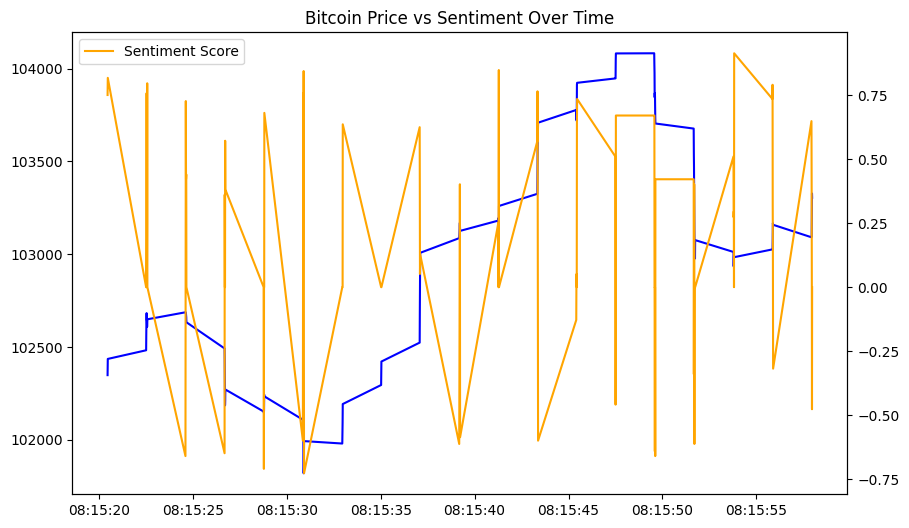

Sentiment Distribution (Box Plot):


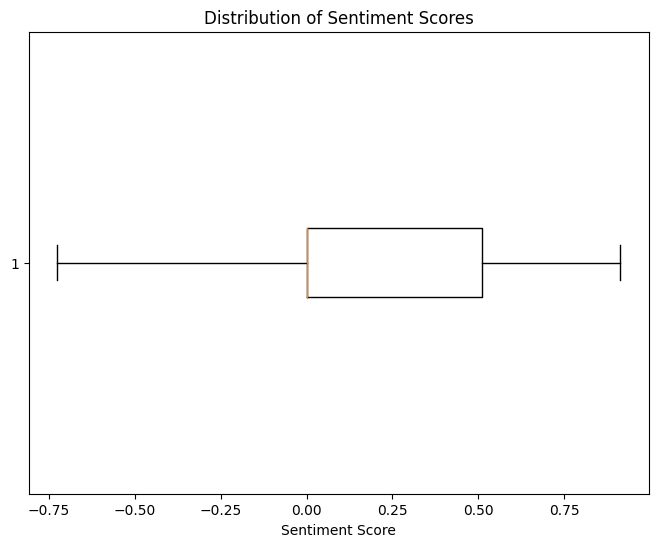

Cumulative Sentiment vs Bitcoin Price (Area Plot):


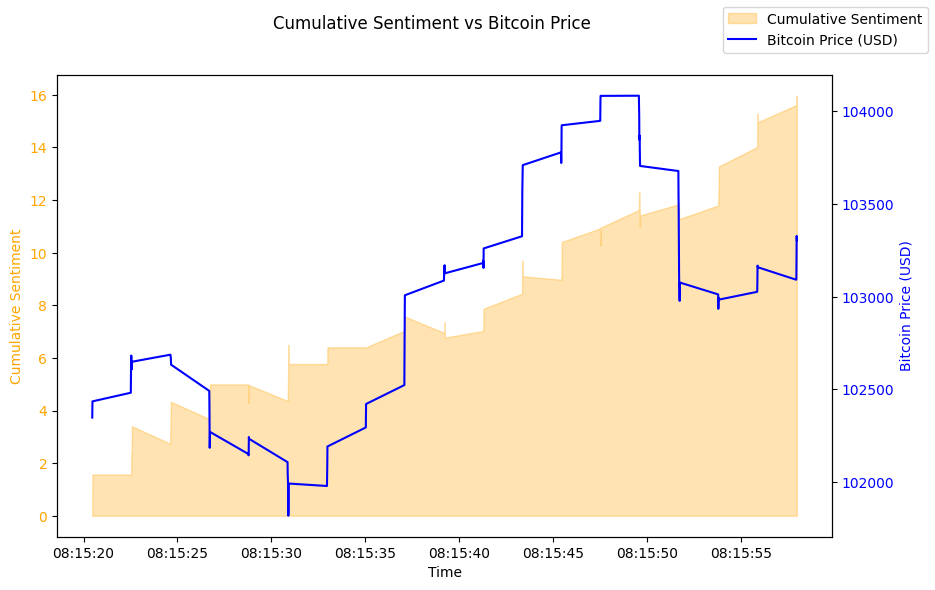

Correlation Heatmap (Sentiment, Price, Price Change, Rolling Correlation):


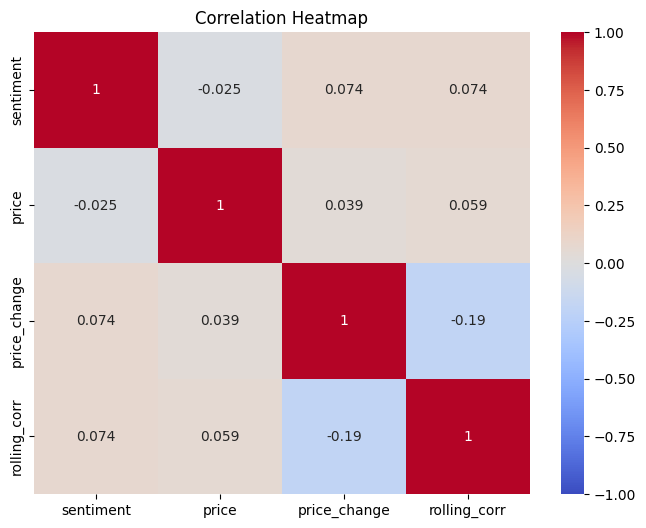

Rolling Correlation Between Sentiment and Price Over Time:


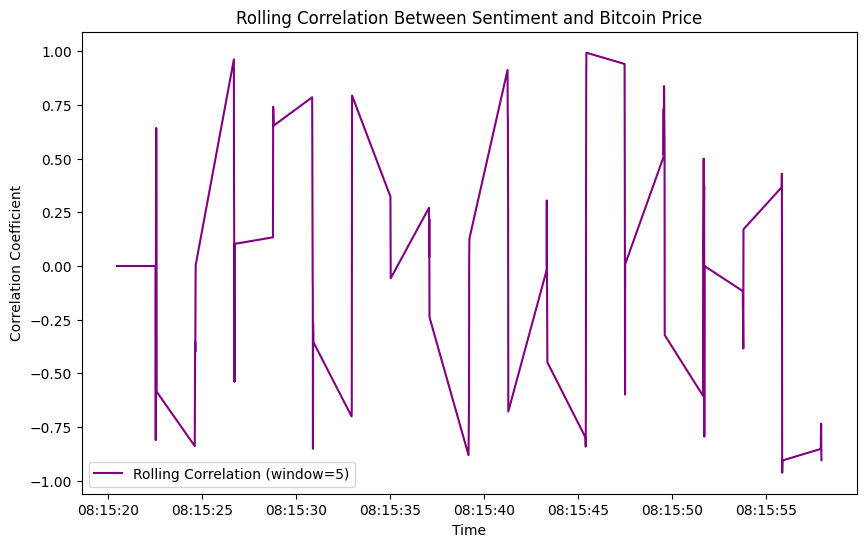

In [5]:
# Enable inline plotting
%matplotlib inline

# Visualize the data
print("Sentiment vs Bitcoin Price Over Time:")
analyzer.visualize_data(combined_df)

# Display Sentiment Distribution Box Plot
print("Sentiment Distribution (Box Plot):")
analyzer.visualize_sentiment_distribution_box(combined_df)

# Display Cumulative Sentiment Area Plot
print("Cumulative Sentiment vs Bitcoin Price (Area Plot):")
analyzer.visualize_cumulative_sentiment_area(combined_df)

# Display Correlation Heatmap
print("Correlation Heatmap (Sentiment, Price, Price Change, Rolling Correlation):")
analyzer.visualize_correlation_heatmap(combined_df)

# Display Rolling Correlation Plot
print("Rolling Correlation Between Sentiment and Price Over Time:")
analyzer.visualize_rolling_correlation(combined_df)